In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import numpy as np

# 讀取資料
user_data = pd.read_csv('user_data.csv')
dp001_prac = pd.read_csv('dp001_prac.csv')
dp001_exam = pd.read_csv('dp001_exam.csv')
dp001_review = pd.read_csv('dp001_review.csv')
dp001_review_plus = pd.read_csv('dp001_review_plus.csv')

In [2]:
# 選擇需要的欄位
scores = user_data[['user_sn', 'chinese_score', 'math_score', 'english_score']]

# 標準化各科成績
scores[['chinese_score', 'math_score', 'english_score']] = scores[['chinese_score', 'math_score', 'english_score']].apply(lambda x: (x - x.mean()) / x.std())

# 加總各科標準化成績
scores['total_score'] = scores[['chinese_score', 'math_score', 'english_score']].sum(axis=1)

# 排序並取前1/4與後1/4
scores = scores.sort_values(by='total_score', ascending=False)
top_quarter = scores.head(len(scores) // 4).reset_index(drop=True)
bottom_quarter = scores.tail(len(scores) // 4).reset_index(drop=True)

# 提取高分組和低分組的user_sn
top_user_sn = top_quarter['user_sn']
bottom_user_sn = bottom_quarter['user_sn']

# 從 dp001_review 中取得高分組和低分組的user_sn對應的資料
top_review_data = dp001_review[dp001_review['user_sn'].isin(top_user_sn)]
bottom_review_data = dp001_review[dp001_review['user_sn'].isin(bottom_user_sn)]

C:\Users\USER\AppData\Local\Temp\ipykernel_20308\3840041761.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scores[['chinese_score', 'math_score', 'english_score']] = scores[['chinese_score', 'math_score', 'english_score']].apply(lambda x: (x - x.mean()) / x.std())
C:\Users\USER\AppData\Local\Temp\ipykernel_20308\3840041761.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scores['total_score'] = scores[['chinese_score', 'math_score', 'english_score']].sum(axis=1)


In [3]:
# 選擇要分析的行為類型
actions_to_count = ['play', 'paused', 'normal', 'speedup', 'slowdown', 'dragstart', 'dragright', 'dragleft', 'note']

# 從高分組和低分組的資料中篩選出對應的 review_sn
top_review_plus_data = dp001_review_plus[dp001_review_plus['review_sn'].isin(top_review_data['review_sn'])]
bottom_review_plus_data = dp001_review_plus[dp001_review_plus['review_sn'].isin(bottom_review_data['review_sn'])]

# 計算高分組每種行為的總次數
top_action_counts = top_review_plus_data[top_review_plus_data['view_action'].isin(actions_to_count)]['view_action'].value_counts().reindex(actions_to_count, fill_value=0)

# 計算低分組每種行為的總次數
bottom_action_counts = bottom_review_plus_data[bottom_review_plus_data['view_action'].isin(actions_to_count)]['view_action'].value_counts().reindex(actions_to_count, fill_value=0)

# 整理結果成為DataFrame
top_action_counts_df = pd.DataFrame(top_action_counts).transpose()
bottom_action_counts_df = pd.DataFrame(bottom_action_counts).transpose()

# 顯示高分組和低分組的行為總次數表格
top_action_counts_df.columns = actions_to_count
bottom_action_counts_df.columns = actions_to_count


In [4]:
# 合併 dp001_review_plus 與 dp001_review 資料，以便將 user_sn 信息加入其中
# 根據 review_sn 進行合併
dp001_review_plus_with_user = dp001_review_plus.merge(dp001_review[['review_sn', 'user_sn']], on='review_sn', how='left')

# 計算每個 user_sn 在高分組中的特定行為次數
top_user_action_counts = (
    dp001_review_plus_with_user[dp001_review_plus_with_user['user_sn'].isin(top_user_sn) & dp001_review_plus_with_user['view_action'].isin(actions_to_count)]
    .groupby(['user_sn', 'view_action']).size()
    .unstack(fill_value=0)
    .reindex(columns=actions_to_count, fill_value=0)
)

# 計算每個 user_sn 在低分組中的特定行為次數
bottom_user_action_counts = (
    dp001_review_plus_with_user[dp001_review_plus_with_user['user_sn'].isin(bottom_user_sn) & dp001_review_plus_with_user['view_action'].isin(actions_to_count)]
    .groupby(['user_sn', 'view_action']).size()
    .unstack(fill_value=0)
    .reindex(columns=actions_to_count, fill_value=0)
)


In [5]:
from scipy.stats import f_oneway

# 準備資料，將高分組和低分組的行為數據展平，以便進行 ANOVA 分析
top_user_action_counts_melted = top_user_action_counts.reset_index().melt(id_vars=['user_sn'], var_name='action', value_name='count')
top_user_action_counts_melted['group'] = 'top'

bottom_user_action_counts_melted = bottom_user_action_counts.reset_index().melt(id_vars=['user_sn'], var_name='action', value_name='count')
bottom_user_action_counts_melted['group'] = 'bottom'

# 合併高分組和低分組的數據
anova_data = pd.concat([top_user_action_counts_melted, bottom_user_action_counts_melted])

# 進行ANOVA分析
anova_results = {}
for action in actions_to_count:
    top_counts = anova_data[(anova_data['group'] == 'top') & (anova_data['action'] == action)]['count']
    bottom_counts = anova_data[(anova_data['group'] == 'bottom') & (anova_data['action'] == action)]['count']
    # ANOVA檢定
    f_stat, p_value = f_oneway(top_counts, bottom_counts)
    anova_results[action] = {'F-statistic': f_stat, 'p-value': p_value}

# 顯示ANOVA結果
anova_results_df = pd.DataFrame(anova_results).transpose()

anova_results_df


,F-statistic,p-value
play,1.116378,0.298864
paused,0.987436,0.328063
normal,0.215018,0.646102
speedup,0.134099,0.716707
slowdown,0.220352,0.642057
dragstart,0.195924,0.661104
dragright,1.178396,0.286053
dragleft,0.001268,0.971824
note,0.623499,0.435749


In [6]:
import numpy as np

# 定義要分析的行為
actions = ['play', 'paused', 'normal', 'speedup', 'slowdown', 'dragstart', 'dragright', 'dragleft', 'note']

# 計算每部影片行為之間的轉移次數
def calculate_transition_counts(review_data, review_plus_data):
    # 合併資料以獲得影片的 user_sn 和 review_sn 之間的對應關係
    merged_data = review_plus_data.merge(review_data[['review_sn', 'video_name']], on='review_sn', how='left')
    
    # 初始化轉移矩陣
    transition_matrix = {video: pd.DataFrame(0, index=actions, columns=actions) for video in merged_data['video_name'].unique()}
    
    # 計算每部影片的轉移次數
    for video, group in merged_data.groupby('video_name'):
        # 排序每個影片的操作以確保轉移順序
        group = group.sort_values(by='view_time')
        # 取出行為序列
        action_sequence = group['view_action'].tolist()
        # 計算轉移次數
        for i in range(len(action_sequence) - 1):
            current_action = action_sequence[i]
            next_action = action_sequence[i + 1]
            if current_action in actions and next_action in actions:
                transition_matrix[video].loc[current_action, next_action] += 1
                
    return transition_matrix

# 計算高分組和低分組的行為轉移矩陣
top_transition_counts = calculate_transition_counts(top_review_data, top_review_plus_data)
bottom_transition_counts = calculate_transition_counts(bottom_review_data, bottom_review_plus_data)

In [7]:
# 將轉移矩陣結果轉換為可視化的 DataFrame 格式
def transition_dict_to_dataframe(transition_matrix_dict):
    # 將每部影片的轉移矩陣轉換為 DataFrame，並加上影片名稱作為層次索引
    return pd.concat(transition_matrix_dict, names=["video_name", "action_from"])

# 將高分組和低分組的轉移矩陣轉換為 DataFrame
top_transition_counts_df = transition_dict_to_dataframe(top_transition_counts)
bottom_transition_counts_df = transition_dict_to_dataframe(bottom_transition_counts)


In [8]:
def calculate_user_transition_counts_fixed(review_data, review_plus_data):
    # 合併資料以獲得 user_sn 的對應關係
    merged_data = review_plus_data.merge(review_data[['review_sn', 'user_sn']], on='review_sn', how='left')
    
    # 初始化空的字典來儲存每個使用者的轉移矩陣
    user_transition_counts = {}

    # 計算每個人的行為轉移次數
    for user, group in merged_data.groupby('user_sn'):
        # 初始化該使用者的轉移矩陣
        transition_matrix = pd.DataFrame(0, index=actions, columns=actions)
        
        # 排序每個使用者的行為順序
        group = group.sort_values(by='view_time')
        action_sequence = group['view_action'].tolist()
        
        # 計算轉移次數
        for i in range(len(action_sequence) - 1):
            current_action = action_sequence[i]
            next_action = action_sequence[i + 1]
            if current_action in actions and next_action in actions:
                transition_matrix.loc[current_action, next_action] += 1
        
        # 存儲該使用者的轉移矩陣
        user_transition_counts[user] = transition_matrix

    return user_transition_counts

# 計算高分組和低分組的個人行為轉移加總次數
top_user_transition_counts_fixed = calculate_user_transition_counts_fixed(top_review_data, top_review_plus_data)
bottom_user_transition_counts_fixed = calculate_user_transition_counts_fixed(bottom_review_data, bottom_review_plus_data)

# 將結果轉換為便於檢視的 DataFrame 格式
top_user_transition_counts_fixed_df = pd.concat(top_user_transition_counts_fixed, names=["user_sn", "action_from"])
bottom_user_transition_counts_fixed_df = pd.concat(bottom_user_transition_counts_fixed, names=["user_sn", "action_from"])

# 將高分組中所有人的行為轉移次數加總，形成一個整體的轉移矩陣
top_group_total_transition_matrix = top_user_transition_counts_fixed_df.groupby("action_from").sum()

# 重新排序高分組的轉移矩陣
top_group_total_transition_matrix = top_group_total_transition_matrix.reindex(index=actions, columns=actions, fill_value=0)

# 計算低分組中所有人的行為轉移次數加總，形成一個整體的轉移矩陣，並按指定順序排序
bottom_group_total_transition_matrix = bottom_user_transition_counts_fixed_df.groupby("action_from").sum()
bottom_group_total_transition_matrix = bottom_group_total_transition_matrix.reindex(index=actions, columns=actions, fill_value=0)




In [9]:
from scipy.stats import chi2_contingency

# 更新卡方檢定方法，忽略次數為零的轉移
chi2_results_filtered = {}

for action_from in actions:
    for action_to in actions:
        # 提取高分組和低分組對應行為轉移的次數
        top_count = top_group_total_transition_matrix.loc[action_from, action_to]
        bottom_count = bottom_group_total_transition_matrix.loc[action_from, action_to]
        
        # 若轉移次數為零，跳過此檢定
        if top_count == 0 and bottom_count == 0:
            continue
        
        # 構造卡方檢定的觀察表
        contingency_table = [[top_count, bottom_count], 
                             [top_group_total_transition_matrix.values.sum() - top_count, 
                              bottom_group_total_transition_matrix.values.sum() - bottom_count]]
        
        # 卡方檢定
        chi2_stat, p_value, _, _ = chi2_contingency(contingency_table)
        chi2_results_filtered[(action_from, action_to)] = {'Chi-square': chi2_stat, 'p-value': p_value}

# 將結果整理成 DataFrame 並顯示
chi2_results_filtered_df = pd.DataFrame(chi2_results_filtered).transpose()

chi2_results_filtered_df


Chi-square       p-value
play      play        16.783518  4.189562e-05
          paused      63.594813  1.528311e-15
          normal      13.812459  2.019923e-04
          speedup      0.000000  1.000000e+00
          slowdown     0.977933  3.227097e-01
          dragstart    5.507652  1.893344e-02
          dragright    5.071063  2.432846e-02
          dragleft     0.256612  6.124571e-01
paused    play         4.320571  3.765428e-02
          paused     177.153174  2.027798e-40
          normal       1.034221  3.091694e-01
          speedup      1.085763  2.974120e-01
          slowdown     3.646054  5.620224e-02
          dragstart    0.543567  4.609584e-01
          dragright    7.117682  7.632733e-03
          dragleft     0.087125  7.678643e-01
          note         0.754777  3.849681e-01
normal    play         3.625533  5.689933e-02
          paused       5.840677  1.565980e-02
          normal       0.927114  3.356140e-01
          speedup      4.352015  3.696519e-02
          slowdown     5.781313  1.619744e-02
          dragstart    1.085763  2.974120e-01
          dragleft     0.068898  7.929484e-01
speedup   play         0.244272  6.211373e-01
          paused       0.000000  1.000000e+00
          normal      12.042235  5.200857e-04
          speedup      1.215098  2.703248e-01
          slowdown     3.383277  6.586099e-02
          dragstart    0.000000  1.000000e+00
slowdown  play         1.215098  2.703248e-01
          paused       3.334546  6.783914e-02
          normal       5.305277  2.126091e-02
          speedup     11.325230  7.646106e-04
          slowdown     5.605257  1.790667e-02
dragstart play         0.000000  1.000000e+00
          paused       2.703017  1.001586e-01
          normal       0.068898  7.929484e-01
          speedup      0.068898  7.929484e-01
          slowdown     0.000000  1.000000e+00
          dragstart    2.785393  9.512736e-02
          dragright    8.873642  2.893173e-03
          dragleft     9.453549  2.107409e-03
dragright play        12.162722  4.875418e-04
          paused       0.659643  4.166860e-01
          speedup      1.178258  2.777109e-01
          dragstart    4.504633  3.380315e-02
          dragright    0.129513  7.189376e-01
          dragleft     0.068898  7.929484e-01
dragleft  play         3.175188  7.476459e-02
          paused       0.425627  5.141425e-01
          normal       0.000000  1.000000e+00
          dragstart   12.678160  3.699515e-04
          dragleft     1.085763  2.974120e-01
note      play         0.754777  3.849681e-01

c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment v

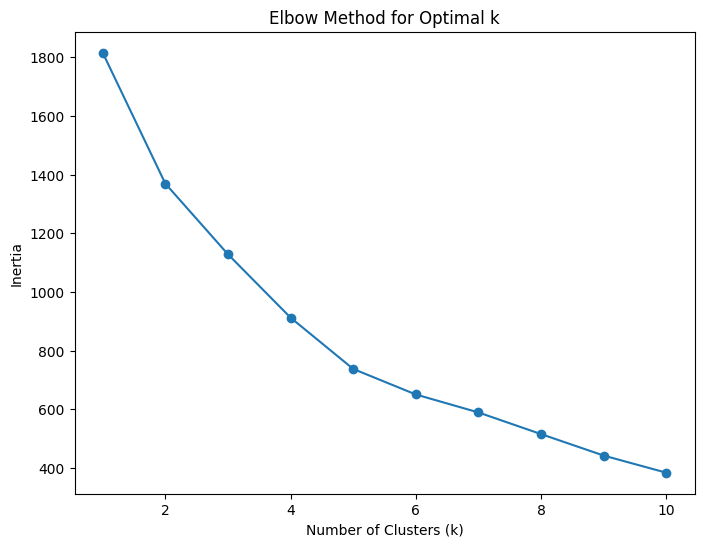

In [10]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# 將高分組與低分組的行為轉移次數矩陣合併成特徵矩陣（行為轉移展平為特徵向量）
# 以便進行聚類分析
all_user_transition_counts = pd.concat([top_user_transition_counts_fixed_df, bottom_user_transition_counts_fixed_df])
all_user_transition_counts = all_user_transition_counts.fillna(0)  # 填充缺失值
feature_matrix = all_user_transition_counts.values.reshape(len(all_user_transition_counts) // len(actions), -1)

# 標準化數據
scaler = StandardScaler()
scaled_features = scaler.fit_transform(feature_matrix)

# 使用手肘法判斷適合的聚類數
inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

# 繪製手肘法圖表
plt.figure(figsize=(8, 6))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()


In [17]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 準備數據：提取每位學習者的行為轉移矩陣並展平成一維特徵向量
# 以高分組和低分組的所有學習者為對象

# 修正過程：展開每位使用者的行為轉移矩陣特徵，並進行聚類
# 1. 將行為轉移矩陣展平成特徵向量格式
user_transition_features_fixed = all_user_transition_counts.unstack(fill_value=0)

# 2. 標準化數據以消除量綱差異
scaler = StandardScaler()
user_transition_features_scaled_fixed = scaler.fit_transform(user_transition_features_fixed)

# 3. 使用 K-means 進行聚類，設置聚類數目為 6
kmeans_fixed = KMeans(n_clusters=6, random_state=0)
cluster_labels_fixed = kmeans_fixed.fit_predict(user_transition_features_scaled_fixed)

# 4. 將聚類結果添加到數據框中，以便分析每位使用者的聚類分配
user_clusters_fixed = pd.DataFrame(index=user_transition_features_fixed.index)
user_clusters_fixed['cluster'] = cluster_labels_fixed

c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


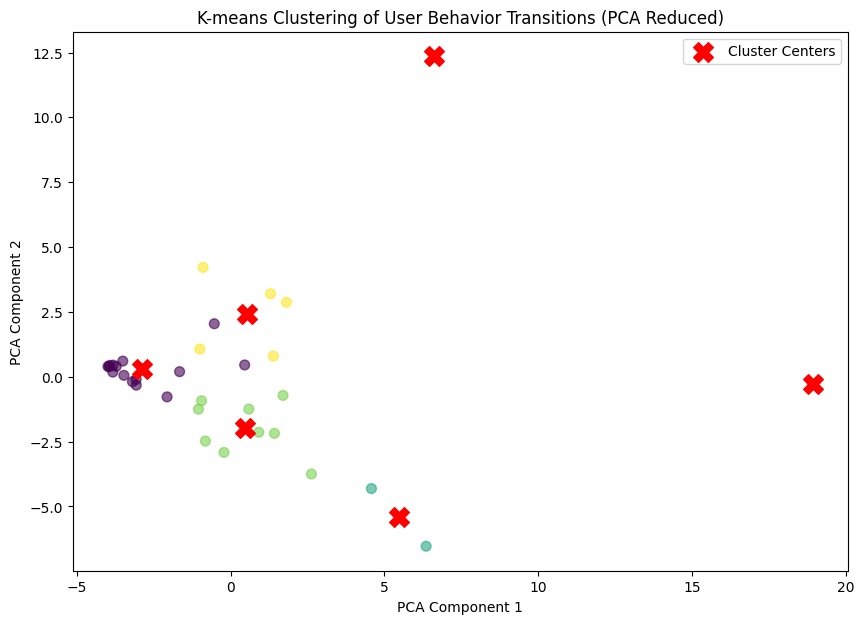

In [19]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 使用 PCA 將特徵向量降維至 2D，便於視覺化
pca = PCA(n_components=2)
user_transition_pca = pca.fit_transform(user_transition_features_scaled_fixed)

# 提取聚類中心點並在 PCA 空間中表示
centroids_pca = pca.transform(kmeans_fixed.cluster_centers_)

# 建立視覺化圖表
plt.figure(figsize=(10, 7))
plt.scatter(user_transition_pca[:, 0], user_transition_pca[:, 1], c=cluster_labels_fixed, cmap='viridis', alpha=0.6, s=50)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], color='red', marker='X', s=200, label='Cluster Centers')
plt.title("K-means Clustering of User Behavior Transitions (PCA Reduced)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()


In [25]:
# 找出聚類中心在外部的兩個群心
# 假設 PCA 結果中群中心的極值代表外部點，找出位於較遠的群心
# 計算所有群心到整體中心點的距離，找出較遠的兩個群心
# 計算整體中心點（用於判斷哪些群中心是外部點）
overall_centroid = np.mean(centroids_pca, axis=0)

# 計算每個群心到整體中心點的歐氏距離
distances_to_overall = np.linalg.norm(centroids_pca - overall_centroid, axis=1)

# 找到距離最大的兩個群心的索引
outer_cluster_indices = np.argsort(distances_to_overall)[-2:]

# 取得這兩個外部群心的 PCA 坐標與群組標籤
outer_centroids = centroids_pca[outer_cluster_indices]
outer_centroid_labels = outer_cluster_indices

outer_centroids, outer_centroid_labels


(array([[ 6.62169237, 12.35750857],
        [18.92282775, -0.28795045]]),
 array([1, 2], dtype=int64))

In [33]:
# 提取兩個外部群組的使用者數據，並分析其行為轉移特徵
# 確認使用者分配的群組，分別提取群組1和群組2的使用者行為轉移矩陣

# 群組1和群組2的使用者
group_1_users = user_clusters_fixed[user_clusters_fixed['cluster'] == 1].index
group_2_users = user_clusters_fixed[user_clusters_fixed['cluster'] == 2].index

# 群組1的行為轉移特徵
group_1_transitions = user_transition_counts_combined.loc[group_1_users].groupby('action_from').sum()

# 群組2的行為轉移特徵
group_2_transitions = user_transition_counts_combined.loc[group_2_users].groupby('action_from').sum()

group_1_transitions = pd.DataFrame(group_1_transitions)
group_2_transitions = pd.DataFrame(group_2_transitions)
group_1_transitions


,play,paused,normal,speedup,slowdown,dragstart,dragright,dragleft,note
action_from,,,,,,,,,
dragleft,20,2,0,0,0,0,0,0,0
dragright,14,0,0,1,0,1,0,0,0
dragstart,16,8,1,0,0,5,14,18,0
normal,2,9,15,3,45,0,0,0,0
note,0,0,0,0,0,0,0,0,0
paused,97,48,2,3,2,47,2,3,0
play,3,168,5,4,7,5,1,3,0
slowdown,2,2,48,3,17,0,0,0,0
speedup,3,1,5,0,0,1,0,0,0


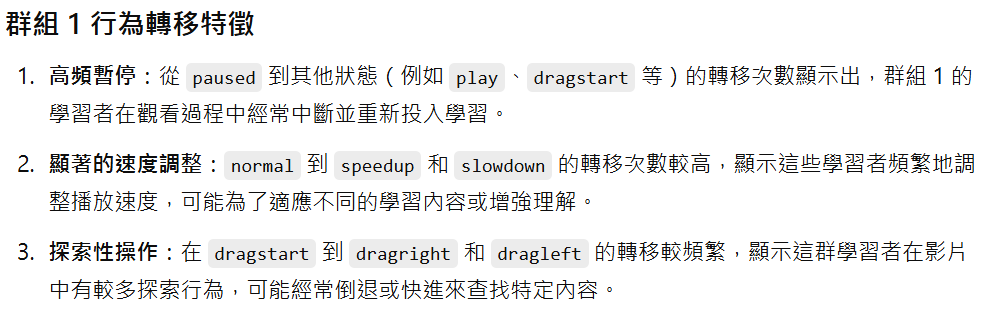

In [34]:
group_2_transitions

,play,paused,normal,speedup,slowdown,dragstart,dragright,dragleft,note
action_from,,,,,,,,,
dragleft,71,12,1,0,0,7,0,0,0
dragright,66,15,0,6,0,3,1,0,0
dragstart,36,44,0,0,1,3,52,69,0
normal,2,46,10,1,39,1,0,0,0
note,0,0,0,0,0,0,0,0,0
paused,283,26,1,1,0,172,14,5,0
play,13,524,52,16,11,32,31,19,0
slowdown,0,2,49,0,8,0,0,0,0
speedup,7,8,1,0,0,1,0,0,0


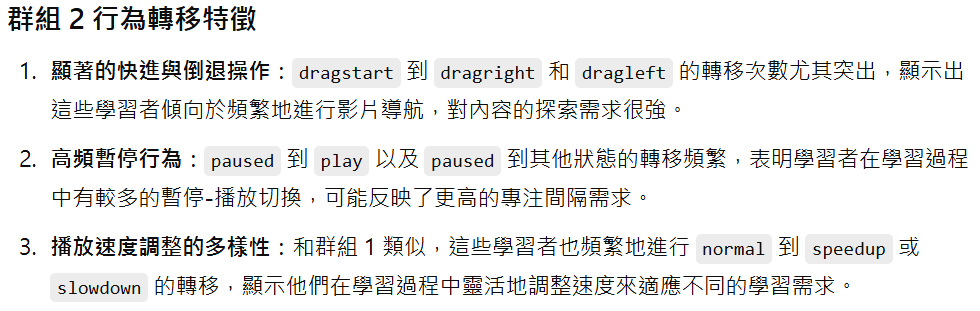

---

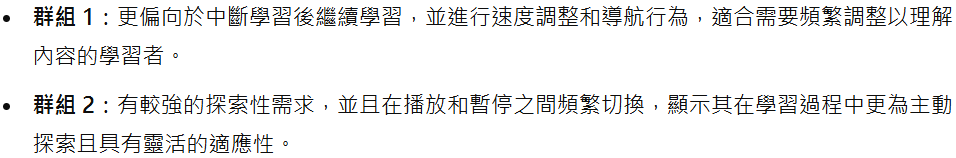